#Analisi del Sentiment sul Bitcoin tramite Tweet

#Obiettivo: eseguire un'analisi del sentiment sui dati raccolti e comprendere come le opinioni riguardanti il Bitcoin nel tempo. In aggiunta, dovrai rispondere a domande cruciali sull'engagement degli utenti sui social media e valutare eventuali correlazioni con il prezzo del Bitcoin.

In [186]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('SparkML').getOrCreate()

Caricamento dataset twitter on BTC

In [187]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Specifica il percorso del tuo file CSV su Google Drive
drive_path = '/content/drive/MyDrive/bitcoin_tweets.csv'

# Controlla se il file esiste
if os.path.exists(drive_path):
    # Carica il file CSV in un DataFrame PySpark
    df = spark.read.csv(drive_path, header=True, inferSchema=True)
    print("DataFrame 'df' creato con successo da bitcoin_tweets.csv")

    # Mostra le prime righe e lo schema del DataFrame
    print("Prime 5 righe del DataFrame:")
    df.show(5)
    print("Schema del DataFrame:")
    df.printSchema()
else:
    print(f"Errore: Il file '{drive_path}' non è stato trovato. Assicurati che esista nel tuo Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame 'df' creato con successo da bitcoin_tweets.csv
Prime 5 righe del DataFrame:
+--------------------+-------------+-------------------+----+--------------------+-------+-----+--------+--------------------+
|                  id|         user|           fullname| url|           timestamp|replies|likes|retweets|                text|
+--------------------+-------------+-------------------+----+--------------------+-------+-----+--------+--------------------+
|1.132977055300300...| KamdemAbdiel|      Abdiel kamdem|NULL|2019-05-27 11:49:...|    0.0|  0.0|     0.0|È appena uscito u...|
|1.132977073402736...|    bitcointe|          Bitcointe|NULL|2019-05-27 11:49:...|    0.0|  0.0|     0.0|Cardano: Digitize...|
|1.132977023893139...|    3eyedbran|Bran - 3 Eyed Raven|NULL|2019-05-27 11:49:...|    0.0|  2.0|     1.0|Another Test twee...|
|1.132977089089556...|D

#1) Analisi dei sentiment dei tweet utilizzando un modello di sentiment analysis. Per ciascun tweet estratto, sarà classificato come positivo, negativo o neutro, basandosi su parole chiave, tono e linguaggio utilizzato. Questa classificazione consentirà di misurare il consenso verso il Bitcoin su base giornaliera.

L’analisi del sentiment è stata condotta mediante un approccio non supervisionato, preceduto da una pipeline di preprocessing NLP in PySpark MLlib, e successivamente aggregata su base temporale per analizzare l’evoluzione del consenso verso il Bitcoin.

In [188]:
!pip install nltk textblob

In [189]:
df = df.filter(df.text.isNotNull())

In [190]:
import nltk
from nltk.corpus import stopwords

# Download the stopwords corpus if it hasn't been downloaded yet
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

nltk_stopwords = stopwords.words('english')

Splittiamo il dataset in trainset e testset

In [191]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

Creiamo una pipeline che esegue la tokenizzazione, rimozione delle stopwords e Bag of Words

In [192]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer

tokenizer = Tokenizer(
    inputCol="text",
    outputCol="tokens"
)

stopwords_remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens",
    stopWords=nltk_stopwords   # 👈 NLTK stopwords
)

vectorizer = CountVectorizer(
    inputCol="filtered_tokens",
    outputCol="features",
    minDF=2    # riduce rumore e errori
)

In [193]:
pipeline = Pipeline(stages=[
    tokenizer,
    stopwords_remover,
    vectorizer
])

Addestriamo il modello

In [194]:
pipeline_model = pipeline.fit(train_df)

In [195]:
train_transformed = pipeline_model.transform(train_df)
test_transformed = pipeline_model.transform(test_df)

In [196]:
train_transformed.select(
    "text", "filtered_tokens", "features"
).show(10, truncate=False)

+-----------------+--------------------+---------------------------+
|text             |filtered_tokens     |features                   |
+-----------------+--------------------+---------------------------+
| #cryptobullscoin|[, #cryptobullscoin]|(38139,[1],[1.0])          |
| #android        |[, #android]        |(38139,[1,10549],[1.0,1.0])|
| $XLM            |[, $xlm]            |(38139,[1,301],[1.0,1.0])  |
| $EOS            |[, $eos]            |(38139,[1,358],[1.0,1.0])  |
| $XLM            |[, $xlm]            |(38139,[1,301],[1.0,1.0])  |
| $OMG            |[, $omg]            |(38139,[1,2171],[1.0,1.0]) |
| $MONA           |[, $mona]           |(38139,[1],[1.0])          |
| $XLM            |[, $xlm]            |(38139,[1,301],[1.0,1.0])  |
| $OCN            |[, $ocn]            |(38139,[1,18284],[1.0,1.0])|
| $BCC            |[, $bcc]            |(38139,[1,2139],[1.0,1.0]) |
+-----------------+--------------------+---------------------------+
only showing top 10 rows


l’analisi del sentiment è stata condotta mediante TextBlob, al fine di catturare il contesto linguistico dei tweet e classificare le reviews in positive, negative e neutral.

In [197]:
from textblob import TextBlob
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
def textblob_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0.05:
        return "positive"
    elif polarity < -0.05:
        return "negative"
    else:
        return "neutral"

In [198]:
sentiment_udf = udf(textblob_sentiment, StringType())

In [199]:
train_sent = train_transformed.withColumn(
    "sentiment",
    sentiment_udf("text")
)

test_sent = test_transformed.withColumn(
    "sentiment",
    sentiment_udf("text")
)

In [200]:
test_sent.select(
    "text", "sentiment"
).show(10, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|text                                                                                                                                                                                                                                                                               |sentiment|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
| $ZEC                                                                                                                                  

In [201]:
from pyspark.sql.functions import to_date

In [202]:
from pyspark.sql.functions import to_date, try_to_timestamp, col, lit

# Prima, si tenta di convertire la colonna 'timestamp' da stringa a tipo timestamp.
# Si usa il formato 'yyyy-MM-dd HH:mm:ssX' che è stato identificato come appropriato in precedenza.
# try_to_timestamp gestisce le stringhe malformate restituendo NULL.
test_sent = test_sent.withColumn(
    "cleaned_timestamp",
    try_to_timestamp(col("timestamp"), lit("yyyy-MM-dd HH:mm:ssX"))
)

# Successivamente, si estrae la data dal timestamp pulito.
test_sent = test_sent.withColumn(
    "date",
    to_date(col("cleaned_timestamp"))
)

# Filtriamo le righe dove la colonna 'date' è NULL, in quanto corrispondono a timestamp non parsabili.
# Includiamo anche un filtro per 'sentiment' NULL per una maggiore robustezza.
test_sent_filtered = test_sent.filter(col("date").isNotNull() & col("sentiment").isNotNull())

sentiment_daily = (
    test_sent_filtered # Usiamo il DataFrame filtrato
    .groupBy("date", "sentiment")
    .count()
    .orderBy("date")
)

sentiment_daily.show()

+----------+---------+-----+
|      date|sentiment|count|
+----------+---------+-----+
|2009-01-11|  neutral|    1|
|2013-08-16|  neutral|    1|
|2015-11-19|  neutral|    1|
|2016-03-28|  neutral|    1|
|2016-05-19|  neutral|    2|
|2016-06-15|  neutral|    1|
|2016-06-16|  neutral|    1|
|2016-09-09|  neutral|    1|
|2016-09-26|  neutral|    1|
|2016-09-29|  neutral|    1|
|2016-12-27| positive|    1|
|2017-02-04|  neutral|    1|
|2017-05-25|  neutral|    1|
|2017-06-30|  neutral|    1|
|2017-07-27|  neutral|    1|
|2017-07-28| positive|    1|
|2017-09-12| positive|    1|
|2017-09-19|  neutral|    1|
|2017-09-22|  neutral|    1|
|2017-11-09|  neutral|    1|
+----------+---------+-----+
only showing top 20 rows


##1.1) Creazione di un grafico temporale che mostri la variazione del sentiment giorno per giorno (un grafico per sentiment a partire da maggio 2019 in quanto nelle date precedenti non si riporta un numero significativo di tweet).


In [203]:
sentiment_daily_wide = sentiment_daily.groupBy("date").pivot("sentiment").sum("count").fillna(0)
sentiment_daily_wide.show(5)

+----------+--------+-------+--------+
|      date|negative|neutral|positive|
+----------+--------+-------+--------+
|2019-05-08|       1|     23|       8|
|2018-08-10|       0|      0|       2|
|2018-06-06|       0|      1|       0|
|2018-06-26|       0|      2|       0|
|2018-11-02|       0|      0|       1|
+----------+--------+-------+--------+
only showing top 5 rows


In [204]:
sentiment_pd = sentiment_daily_wide.toPandas()

# ordina per data ascendente
sentiment_pd = sentiment_pd.sort_values("date")

# mostra le prime 10 righe
sentiment_pd.head(10)

,date,negative,neutral,positive
151,2009-01-11,0,1,0
198,2013-08-16,0,1,0
182,2015-11-19,0,1,0
224,2016-03-28,0,1,0
239,2016-05-19,0,2,0
73,2016-06-15,0,1,0
17,2016-06-16,0,1,0
34,2016-09-09,0,1,0
28,2016-09-26,0,1,0
280,2016-09-29,0,1,0


In [205]:
from pyspark.sql.functions import col

null_dates_count = sentiment_daily_wide.filter(col("date").isNull()).count()
null_dates_count

0

In [206]:
import pandas as pd

sentiment_pd = sentiment_daily_wide.toPandas()

# converti in datetime
sentiment_pd['date'] = pd.to_datetime(sentiment_pd['date'])

# ordina e setta l'indice
sentiment_pd = sentiment_pd.sort_values('date').set_index('date')

In [207]:
from pyspark.sql.functions import col

null_dates_count_2019 = (
    sentiment_daily_wide
    .filter(col("date").isNull() | (col("date") < "2019-01-01"))
    .count()
)

null_dates_count_2019

211

In [208]:
sentiment_daily_wide_2019 = (
    sentiment_daily_wide
    .filter(col("date").isNotNull())
    .filter(col("date") >= "2019-05-01")
)

In [209]:
import pandas as pd

sentiment_pd = sentiment_daily_wide_2019.toPandas()
sentiment_pd['date'] = pd.to_datetime(sentiment_pd['date'])
sentiment_pd = sentiment_pd.sort_values("date").set_index("date")

idx = pd.date_range(start=sentiment_pd.index.min(), end=sentiment_pd.index.max(), freq='D')
sentiment_pd = sentiment_pd.reindex(idx, fill_value=0)

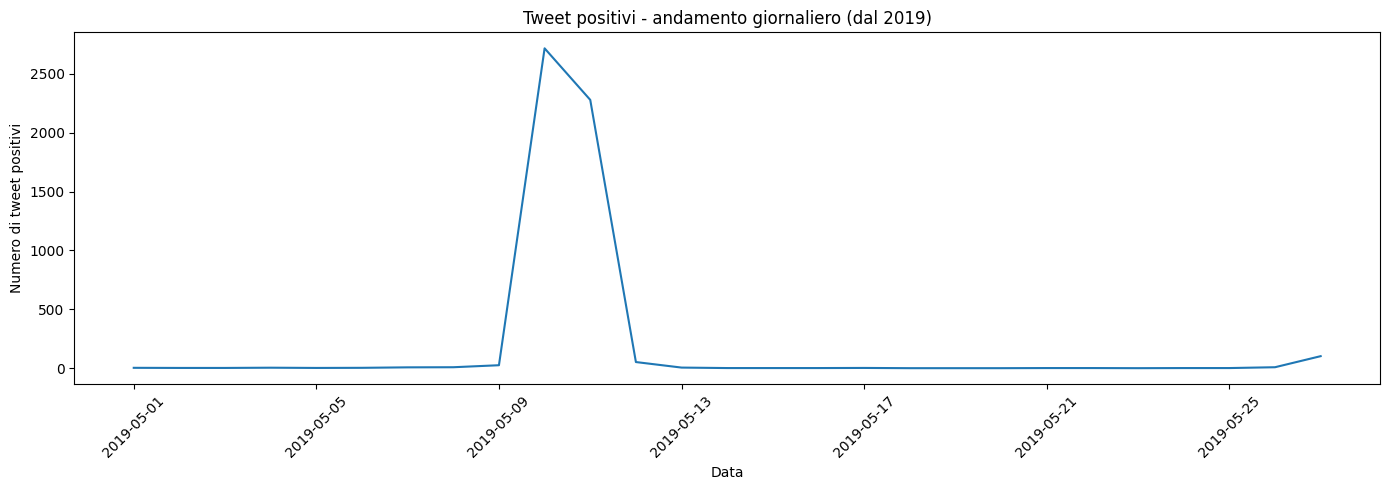

In [210]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(sentiment_pd.index, sentiment_pd['positive'])
plt.title("Tweet positivi - andamento giornaliero (dal 2019)")
plt.xlabel("Data")
plt.ylabel("Numero di tweet positivi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

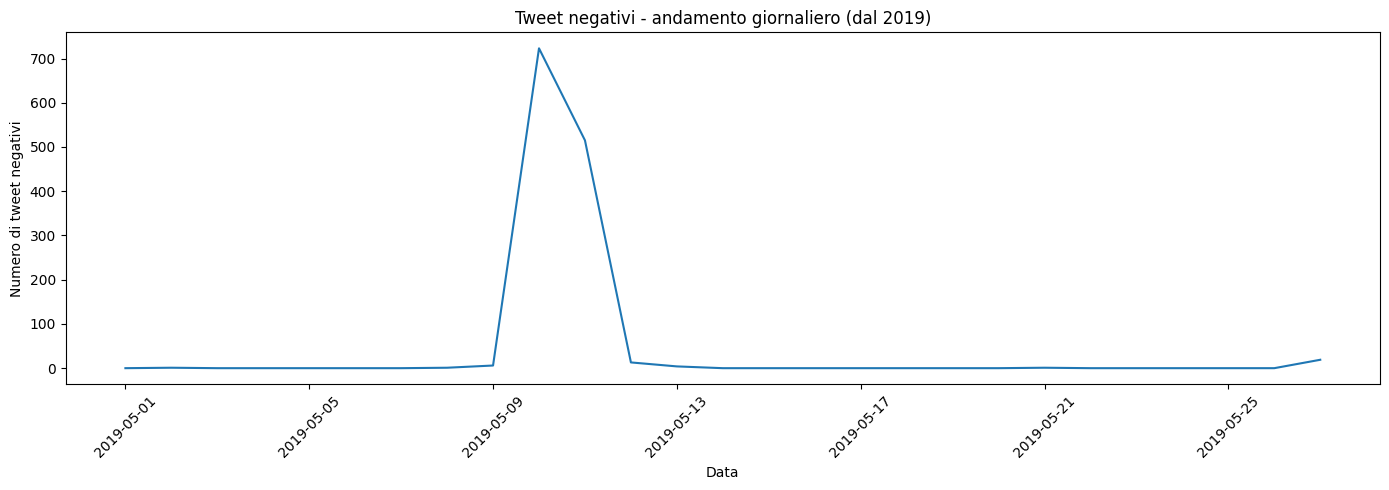

In [211]:
plt.figure(figsize=(14,5))
plt.plot(sentiment_pd.index, sentiment_pd['negative'])
plt.title("Tweet negativi - andamento giornaliero (dal 2019)")
plt.xlabel("Data")
plt.ylabel("Numero di tweet negativi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

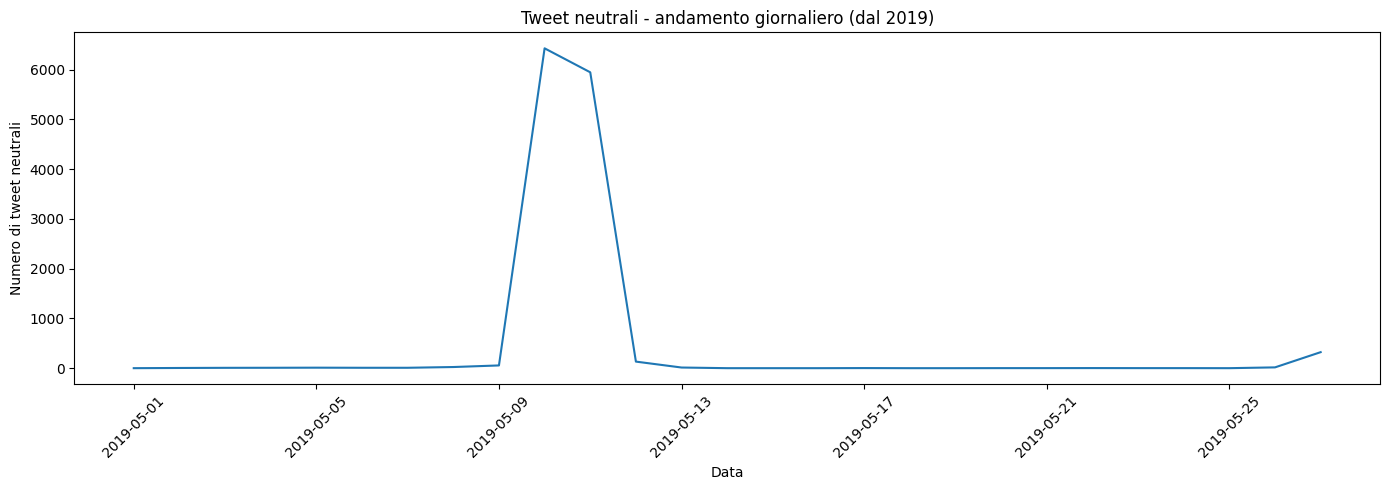

In [212]:
plt.figure(figsize=(14,5))
plt.plot(sentiment_pd.index, sentiment_pd['neutral'])
plt.title("Tweet neutrali - andamento giornaliero (dal 2019)")
plt.xlabel("Data")
plt.ylabel("Numero di tweet neutrali")
plt.xticks(rotation=45)
plt.tight_layout()

Conclusione: dalla lettura dei grafici sopra esposti emerge chiaramente un aumento dei tweet (di qualsiasi sentiment) nel periodo che intercorre dal 9 maggio 2019 al 13 maggio dello stesso anno. Con un trend crescente verso la fine del mese.


# 2) Dopo l'analisi del sentiment Valutiamo l'engagement generato dai tweet. In particolare, rispondiamo alle seguenti domande:
- I tweet negativi ricevono più likes rispetto ai tweet positivi? Verranno calcolate e confrontate le medie di like per i tweet negativi e positivi, analizzando se i tweet con un tono negativo attirano maggiore attenzione o interesse.
- I tweet negativi ricevono più interazioni (risposte) rispetto ai tweet positivi?
Sarà condotta un'analisi simile confrontando il numero medio di risposte tra tweet positivi e negativi, per vedere quale tipo di sentiment provoca una discussione più accesa.

In [213]:
from pyspark.sql.functions import to_date, try_to_timestamp, col, lit

# Ensure train_sent has the same 'cleaned_timestamp' and 'date' columns as test_sent
train_sent_aligned = train_sent.withColumn(
    "cleaned_timestamp",
    try_to_timestamp(col("timestamp"), lit("yyyy-MM-dd HH:mm:ssX"))
).withColumn(
    "date",
    to_date(col("cleaned_timestamp"))
)

# Now, perform the union with the schema-aligned DataFrames
df_with_sentiment = train_sent_aligned.unionByName(test_sent)

In [214]:
df_with_sentiment.select(
    "text", "sentiment", "likes", "replies"
).show(10, truncate=False)

+-----------------+---------+----------------+----------------+
|text             |sentiment|likes           |replies         |
+-----------------+---------+----------------+----------------+
| #cryptobullscoin|neutral  | #cryptocurrency| #cryptobulls   |
| #android        |neutral  | #blockchain    | #cryptocurrency|
| $XLM            |neutral  | $NEO           | $DGB           |
| $EOS            |neutral  | $ADA           | $NEO           |
| $XLM            |neutral  | $IOST          | $BCH           |
| $OMG            |neutral  | $LTC           | $TRIG          |
| $MONA           |neutral  | $NEO           | $IOST          |
| $XLM            |neutral  | $KMD           | $NEO           |
| $OCN            |neutral  | $NEO           | $EOS           |
| $BCC            |neutral  | $EOS           | $BNB           |
+-----------------+---------+----------------+----------------+
only showing top 10 rows


In [215]:
df_with_sentiment.printSchema()

root
 |-- id: string (nullable = true)
 |-- user: string (nullable = true)
 |-- fullname: string (nullable = true)
 |-- url: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- replies: string (nullable = true)
 |-- likes: string (nullable = true)
 |-- retweets: string (nullable = true)
 |-- text: string (nullable = true)
 |-- tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- features: vector (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- cleaned_timestamp: timestamp (nullable = true)
 |-- date: date (nullable = true)



In [216]:
from pyspark.sql.functions import col

df_engagement = (
    df_with_sentiment
    .filter(col("sentiment").isin("positive", "negative"))
    .filter(col("likes").isNotNull())
    .filter(col("replies").isNotNull())
)

In [217]:
df_engagement.groupBy("sentiment").count().show()

+---------+-----+
|sentiment|count|
+---------+-----+
| positive|27045|
| negative| 6732|
+---------+-----+



In [218]:
from pyspark.sql.functions import avg

avg_likes = (
    df_engagement
    .groupBy("sentiment")
    .agg(avg("likes").alias("avg_likes"))
)

avg_likes.show()


+---------+-----------------+
|sentiment|        avg_likes|
+---------+-----------------+
| positive|8.373081900536144|
| negative|8.627005347593583|
+---------+-----------------+



In [219]:
avg_replies = (
    df_engagement
    .groupBy("sentiment")
    .agg(avg("replies").alias("avg_replies"))
)

avg_replies.show()

+---------+------------------+
|sentiment|       avg_replies|
+---------+------------------+
| positive|1.1488260306895914|
| negative|0.9523172905525846|
+---------+------------------+



In [220]:
avg_likes_pd = avg_likes.toPandas()
avg_replies_pd = avg_replies.toPandas()

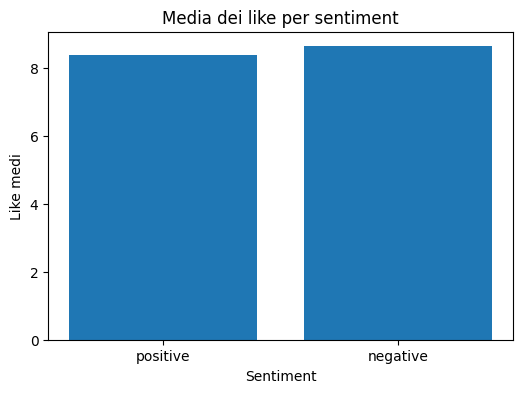

In [221]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(avg_likes_pd['sentiment'], avg_likes_pd['avg_likes'])
plt.title("Media dei like per sentiment")
plt.ylabel("Like medi")
plt.xlabel("Sentiment")
plt.show()

Conclusione: I like si distribuiscono in media alla stessa maniera sulle positive e negative reviews

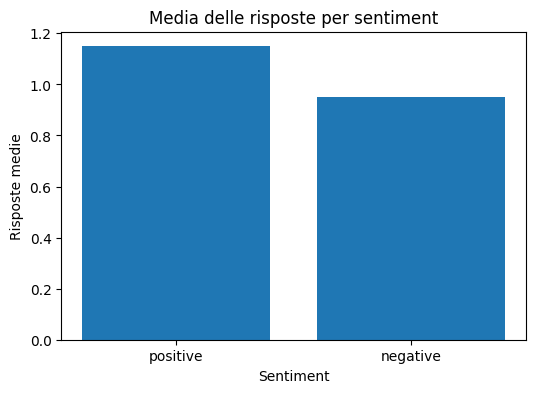

In [222]:
plt.figure(figsize=(6,4))
plt.bar(avg_replies_pd['sentiment'], avg_replies_pd['avg_replies'])
plt.title("Media delle risposte per sentiment")
plt.ylabel("Risposte medie")
plt.xlabel("Sentiment")
plt.show()

Conclusione: I tweet negativi ricevono in media più risposte rispetto ai tweet positivi.

#3) Per aggiungere ulteriore profondità all'analisi, esploriamo la relazione tra la variazione del sentiment e la variazione del valore del Bitcoin.

Confrontiamo le variazioni del sentiment giornaliero con le variazioni del prezzo del Bitcoin, cercando di individuare correlazioni significative.

Inseriamo lo storico del prezzo del Bitcoin (BTC/USD).

In [223]:

# Specifica il percorso del tuo file CSV su Google Drive
drive_path = '/content/drive/MyDrive/BTC-USD.csv'

# Controlla se il file esiste
if os.path.exists(drive_path):
    # Carica il file CSV in un DataFrame PySpark
    btc_df = spark.read.csv(drive_path, header=True, inferSchema=True)
    print("DataFrame 'btc_df' creato con successo da BTC_USD.csv")

    # Mostra le prime righe e lo schema del DataFrame
    print("Prime 5 righe del DataFrame:")
    btc_df.show(5)
    print("Schema del DataFrame:")
    btc_df.printSchema()
else:
    print(f"Errore: Il file '{drive_path}' non è stato trovato. Assicurati che esista nel tuo Google Drive.")

DataFrame 'btc_df' creato con successo da BTC_USD.csv
Prime 5 righe del DataFrame:
+-------------------+-----------------+------------------+------------------+------------------+--------+---------+------------+
|               Date|             Open|              High|               Low|             Close|  Volume|Dividends|Stock Splits|
+-------------------+-----------------+------------------+------------------+------------------+--------+---------+------------+
|2014-09-17 00:00:00| 465.864013671875|468.17401123046875| 452.4219970703125| 457.3340148925781|21056800|      0.0|         0.0|
|2014-09-18 00:00:00|456.8599853515625| 456.8599853515625|   413.10400390625|424.44000244140625|34483200|      0.0|         0.0|
|2014-09-19 00:00:00|424.1029968261719| 427.8349914550781| 384.5320129394531| 394.7959899902344|37919700|      0.0|         0.0|
|2014-09-20 00:00:00|394.6730041503906| 423.2959899902344|389.88299560546875|408.90399169921875|36863600|      0.0|         0.0|
|2014-09-21 00

Creiamo un sentiment score per giorno calcolando la media dei sentiment per il giorno di riferimento, dove -1 consiste in negative e 1 in positive.

In [224]:
from pyspark.sql.functions import when, col

df_with_sentiment = df_with_sentiment.withColumn(
    "sentiment_numeric",
    when(col("sentiment") == "positive", 1)
    .when(col("sentiment") == "negative", -1)
    .otherwise(0)
)

In [225]:
sentiment_daily_score = (
    df_with_sentiment
    .groupBy("date")
    .agg({"sentiment_numeric": "avg"})
    .withColumnRenamed("avg(sentiment_numeric)", "daily_sentiment_score")
)

In [226]:
from pyspark.sql.functions import to_date

btc_df = btc_df.withColumn("date", to_date(col("date")))

Effettuiamo una inner join che ci permette di unire il dataset dell'evoluzione dei prezzi e quello dei sentiment scores


In [227]:
sentiment_btc = sentiment_daily_score.join(btc_df, on="date", how="inner")

In [228]:
sentiment_btc.printSchema()
sentiment_btc.show(5, truncate=False)

root
 |-- date: date (nullable = true)
 |-- daily_sentiment_score: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)

+----------+---------------------+----------------+----------------+----------------+----------------+-----------+---------+------------+
|date      |daily_sentiment_score|Open            |High            |Low             |Close           |Volume     |Dividends|Stock Splits|
+----------+---------------------+----------------+----------------+----------------+----------------+-----------+---------+------------+
|2018-05-28|0.0                  |7371.31005859375|7419.0498046875 |7100.89013671875|7135.990234375  |5040600064 |0.0      |0.0         |
|2018-08-10|0.4                  |6571.419921875  |6591.259765625  |6124.52001953125|6184.

Calcoliamo una metrica chiamata btc_return che consiste nella variazione del prezzo (preso dal campo close) con il giorno precedente.

In [229]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, col

window_spec = Window.orderBy("date")

sentiment_btc = sentiment_btc.withColumn(
    "btc_return",
    col("close") - lag("close", 1).over(window_spec)
)

In [230]:
sentiment_btc.printSchema()
sentiment_btc.show(5, truncate=False)

root
 |-- date: date (nullable = true)
 |-- daily_sentiment_score: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)
 |-- btc_return: double (nullable = true)

+----------+---------------------+------------------+------------------+------------------+------------------+--------+---------+------------+-------------------+
|date      |daily_sentiment_score|Open              |High              |Low               |Close             |Volume  |Dividends|Stock Splits|btc_return         |
+----------+---------------------+------------------+------------------+------------------+------------------+--------+---------+------------+-------------------+
|2014-10-03|0.0                  |375.1809997558594 |377.69500732421875|357.8590087890625 |359.5119934082031 |3

Guardiamo anzitutto l'andamento del prezzo di BTC nel tempo

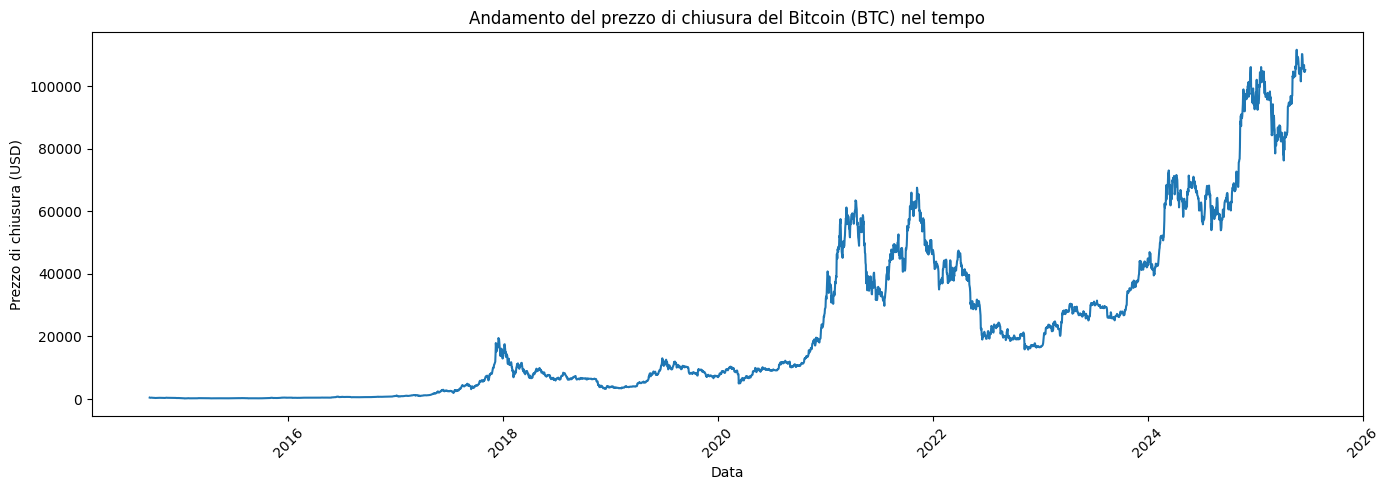

In [231]:
import matplotlib.pyplot as plt

# Converti in pandas
price_pd = btc_df.select("date", "close").orderBy("date").toPandas()

# Grafico
plt.figure(figsize=(14,5))
plt.plot(price_pd["date"], price_pd["close"])
plt.title("Andamento del prezzo di chiusura del Bitcoin (BTC) nel tempo")
plt.xlabel("Data")
plt.ylabel("Prezzo di chiusura (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Avendo un numero significativo di tweets solo dal 2018 di seguito viene mostrato l'andamento del sentiment solo da tale anno

In [232]:
sentiment_time_pd = sentiment_daily_score \
    .orderBy("date") \
    .toPandas()

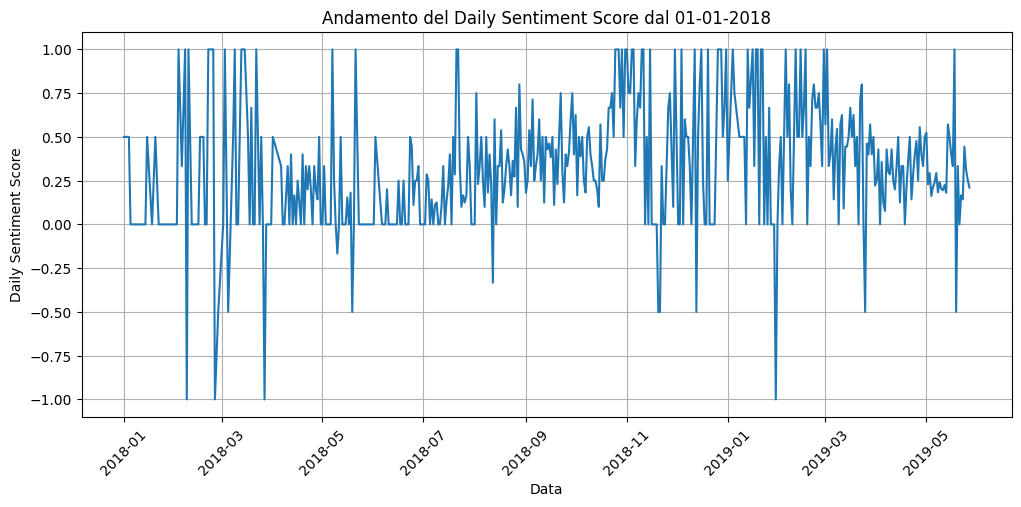

In [233]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) converti in pandas e ordina
sentiment_time_pd = sentiment_daily_score.orderBy("date").toPandas()

# 2) converti in datetime (se non lo è già)
sentiment_time_pd["date"] = pd.to_datetime(sentiment_time_pd["date"])

# 3) filtra dal 2018
sentiment_time_pd = sentiment_time_pd[sentiment_time_pd["date"] >= "2018-01-01"]

# 4) grafico
plt.figure(figsize=(12, 5))
plt.plot(sentiment_time_pd["date"], sentiment_time_pd["daily_sentiment_score"])
plt.title("Andamento del Daily Sentiment Score dal 01-01-2018")
plt.xlabel("Data")
plt.ylabel("Daily Sentiment Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Calcoliamo l'indice di correlazione

In [234]:
corr_return = sentiment_btc.stat.corr("daily_sentiment_score", "btc_return")
corr_return

-0.009364071759424188

In [235]:
from pyspark.sql.functions import col

corr_return_2018 = sentiment_btc \
    .filter(col("date") >= "2018-01-01") \
    .stat.corr("daily_sentiment_score", "btc_return")

corr_return_2018

-0.004309898911045045

Conclusione: Sembra non esserci alcuna correlazione in quanto l'indice è pressochè zero.

Creazione di un grafico che mostri in sovrapposizione sia l'andamento del prezzo che quello del sentiment score nel tempo.

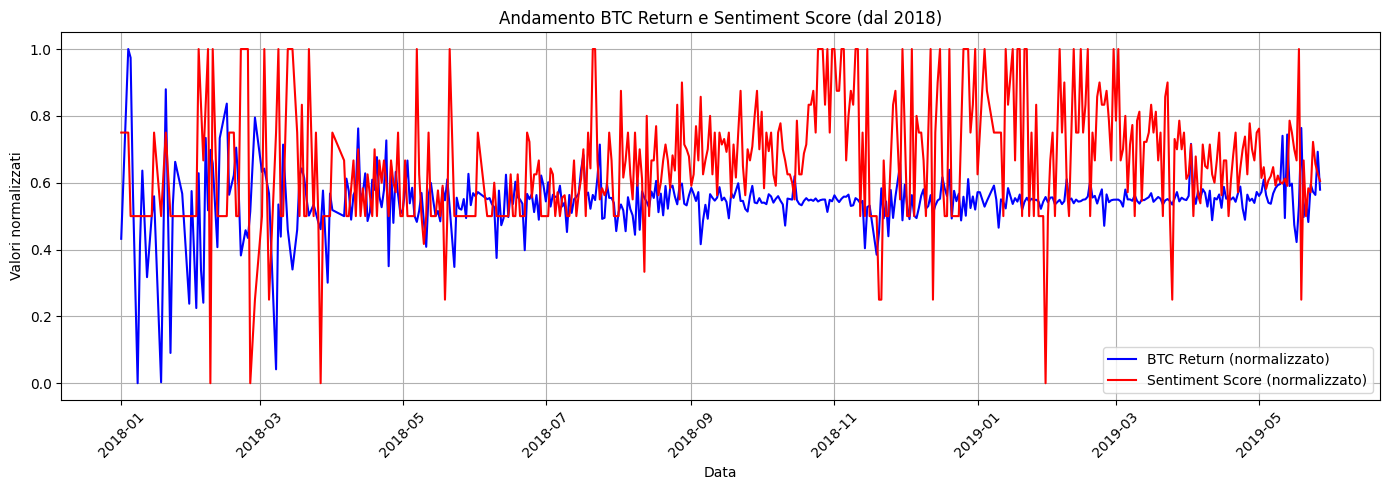

In [238]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) prendi solo i giorni in comune
common_df = sentiment_btc.select("date", "daily_sentiment_score", "btc_return")

# 2) converti in pandas e ordina
common_pd = common_df.orderBy("date").toPandas()
common_pd["date"] = pd.to_datetime(common_pd["date"])

# 3) filtra dal 2018
common_pd = common_pd[common_pd["date"] >= "2018-01-01"]

# 4) normalizza le serie (0-1)
common_pd["return_norm"] = (common_pd["btc_return"] - common_pd["btc_return"].min()) / (common_pd["btc_return"].max() - common_pd["btc_return"].min())
common_pd["sent_norm"] = (common_pd["daily_sentiment_score"] - common_pd["daily_sentiment_score"].min()) / (common_pd["daily_sentiment_score"].max() - common_pd["daily_sentiment_score"].min())

# 5) grafico sovrapposto
plt.figure(figsize=(14,5))
plt.plot(common_pd["date"], common_pd["return_norm"], label="BTC Return (normalizzato)", color="blue")
plt.plot(common_pd["date"], common_pd["sent_norm"], label="Sentiment Score (normalizzato)", color="red")

plt.title("Andamento BTC Return e Sentiment Score (dal 2018)")
plt.xlabel("Data")
plt.ylabel("Valori normalizzati")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

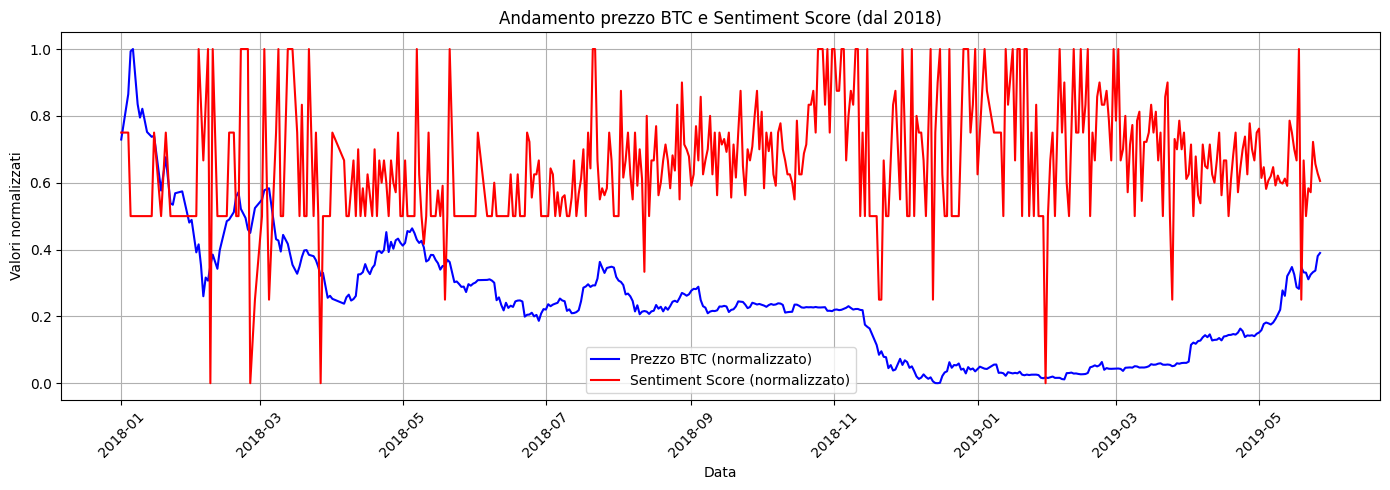

In [239]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) prendi solo i giorni in comune
common_df = sentiment_btc.select("date", "daily_sentiment_score", "close")

# 2) converti in pandas e ordina
common_pd = common_df.orderBy("date").toPandas()
common_pd["date"] = pd.to_datetime(common_pd["date"])

# 3) filtra dal 2018
common_pd = common_pd[common_pd["date"] >= "2018-01-01"]

# 4) normalizza le serie (0-1)
common_pd["close_norm"] = (
    (common_pd["close"] - common_pd["close"].min()) /
    (common_pd["close"].max() - common_pd["close"].min())
)

common_pd["sent_norm"] = (
    (common_pd["daily_sentiment_score"] - common_pd["daily_sentiment_score"].min()) /
    (common_pd["daily_sentiment_score"].max() - common_pd["daily_sentiment_score"].min())
)

# 5) grafico sovrapposto
plt.figure(figsize=(14,5))
plt.plot(common_pd["date"], common_pd["close_norm"], label="Prezzo BTC (normalizzato)", color="blue")
plt.plot(common_pd["date"], common_pd["sent_norm"], label="Sentiment Score (normalizzato)", color="red")

plt.title("Andamento prezzo BTC e Sentiment Score (dal 2018)")
plt.xlabel("Data")
plt.ylabel("Valori normalizzati")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Conclusione: Anche dai grafici non è emersa alcuna correlazione

  Analisi dei peaks

In [236]:
from pyspark.sql.functions import col

# ordina per sentiment score
top_peaks = sentiment_btc.orderBy(col("daily_sentiment_score").desc()).limit(5)
bottom_peaks = sentiment_btc.orderBy(col("daily_sentiment_score").asc()).limit(5)

# unisci in un unico DataFrame
peaks = top_peaks.union(bottom_peaks)

# mostra i campi importanti
peaks.select("date", "daily_sentiment_score", "btc_return").show(truncate=False)

+----------+---------------------+-------------------+
|date      |daily_sentiment_score|btc_return         |
+----------+---------------------+-------------------+
|2016-05-15|1.0                  |7.264007568359375  |
|2017-06-06|1.0                  |558.219970703125   |
|2016-10-06|1.0                  |7.3280029296875    |
|2016-12-27|1.0                  |197.593994140625   |
|2015-09-02|1.0                  |-28.037017822265625|
|2017-08-17|-1.0                 |989.219970703125   |
|2018-02-25|-1.0                 |-148.33984375      |
|2017-12-08|-1.0                 |-1330.298828125    |
|2018-02-08|-1.0                 |644.2900390625     |
|2018-03-27|-1.0                 |-376.3603515625    |
+----------+---------------------+-------------------+



In [240]:
from pyspark.sql.functions import col

# picchi positivi del btc_return
top_return_peaks = sentiment_btc.orderBy(col("btc_return").desc()).limit(5)

# picchi negativi del btc_return
bottom_return_peaks = sentiment_btc.orderBy(col("btc_return").asc()).limit(5)

# unisci
return_peaks = top_return_peaks.union(bottom_return_peaks)

# mostra la tabella
return_peaks \
    .select("date", "btc_return", "daily_sentiment_score") \
    .orderBy("date") \
    .show(truncate=False)

+----------+----------------+---------------------+
|date      |btc_return      |daily_sentiment_score|
+----------+----------------+---------------------+
|2014-10-03|NULL            |0.0                  |
|2017-12-06|2374.7998046875 |1.0                  |
|2017-12-07|3608.19921875   |0.0                  |
|2017-12-12|1960.0          |0.0                  |
|2017-12-20|-2872.80078125  |0.0                  |
|2018-01-04|1942.0          |0.5                  |
|2018-01-05|1830.2998046875 |0.0                  |
|2018-01-08|-2356.900390625 |0.0                  |
|2018-01-18|-2344.8994140625|0.0                  |
|2018-03-08|-2178.2900390625|0.5                  |
+----------+----------------+---------------------+



Anche da un'analisi dei picchi alti e bassi non emerge nulla di significativo